# Online Retail Exploratory Data Analysis

## Overview
This notebook analyzes the cleaned Online Retail dataset to uncover actionable business insights for marketing, operations, and product teams.

**Data Size:** 535,185 transactions (8 columns)

In [178]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

# 1. Load Cleaned Data

In [179]:
df=pd.read_csv("../data/processed/online_retail_data_clean.csv")

In [180]:
df.shape

(535185, 8)

In [181]:
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

In [182]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 535185 entries, 0 to 535184
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   invoiceno    535185 non-null  object        
 1   stockcode    535185 non-null  object        
 2   description  535185 non-null  object        
 3   quantity     535185 non-null  int64         
 4   invoicedate  535185 non-null  datetime64[ns]
 5   unitprice    535185 non-null  float64       
 6   customerid   401604 non-null  float64       
 7   country      535185 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.7+ MB


In [183]:
df.sample(10)

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
269418,560772,90160B,red_boudicca_large_bracelet,1,2011-07-20 16:12:00,7.07,NaN,united_kingdom
29665,538852,22719,gumball_monochrome_coat_rack,1,2010-12-14 13:33:00,1.25,17372.0,united_kingdom
136193,548171,21094,set/6_red_spotty_paper_plates,96,2011-03-29 13:58:00,0.64,16422.0,united_kingdom
377123,569866,22554,plasters_in_tin_woodland_animals,2,2011-10-06 14:50:00,1.65,12757.0,portugal
133421,547881,22692,doormat_welcome_to_our_home,1,2011-03-27 16:08:00,7.95,13110.0,united_kingdom
381409,570215,23353,6_gift_tags_vintage_christmas,1,2011-10-09 11:53:00,0.83,16066.0,united_kingdom
253482,559494,22457,natural_slate_heart_chalkboard,1,2011-07-08 13:54:00,5.79,NaN,united_kingdom
532643,581439,90114,summer_daisies_bag_charm,2,2011-12-08 16:30:00,2.46,NaN,united_kingdom
284165,562105,22725,alarm_clock_bakelike_chocolate,4,2011-08-02 14:50:00,3.75,15271.0,united_kingdom
72328,542344,21212,pack_of_72_retrospot_cake_cases,5,2011-01-27 11:30:00,1.25,NaN,united_kingdom


# 2. Feature Engineering

Creating `revenue` and `is_return` columns for deeper analysis.

In [184]:
df['revenue']=df['quantity']*df['unitprice']

In [185]:
df[['quantity', 'unitprice', 'revenue']].sample(10)

,quantity,unitprice,revenue
13215,20,1.66,33.20
479190,7,0.85,5.95
523224,32,9.13,292.16
41507,1,16.98,16.98
94576,2,1.25,2.50
246825,10,2.08,20.80
334824,4,2.95,11.80
413953,24,0.42,10.08
372206,4,1.45,5.80
21906,1,1.95,1.95


In [186]:
df["is_return"] = np.where(df["quantity"] < 0, 1, 0)

In [187]:
df[['quantity','is_return']].sample(10)

,quantity,is_return
12834,2,0
201246,12,0
43302,1,0
276935,4,0
301837,48,0
215248,3,0
163772,1,0
519313,2,0
412987,12,0
377870,2,0


# 3. Key Business Metrics

Quick snapshot of overall business performance.

### Total Revenue

In [188]:
print(df["revenue"].sum())

9748131.074


### Unique Customers

In [189]:
df['customerid'].nunique()

4372

### Unique Invoices

In [190]:
df['invoiceno'].nunique()

24444

### Non-Return Transactions (Rows)

In [191]:
len(df[df['is_return']==0])

525460

### Average Order Value (AOV)

In [192]:
print((df["revenue"].sum())/df['invoiceno'].nunique())

398.7944311078383


### Return Transactions (Rows)

In [193]:
len(df[df['is_return']==1])

9725

### Return Rate (%)

In [194]:
print((df['is_return'].mean())*100)

1.817128656445902


### Total Quantity Sold (Non-Return)

In [195]:
print(df[df['is_return']==0]['quantity'].sum())

5612470


# 4. Revenue by Country

### Which countries generate the most revenue?

In [196]:
country_revenue = (
    df.groupby("country")["revenue"]
      .sum()
      .sort_values(ascending=False)
)

country_revenue

country
united_kingdom          8189252.304
netherlands              284661.540
eire                     262993.380
germany                  221509.470
france                   197317.110
australia                137009.770
switzerland               56363.050
spain                     54756.030
belgium                   40910.960
sweden                    36585.410
japan                     35340.620
norway                    35163.460
portugal                  29302.970
finland                   22326.740
channel_islands           20076.390
denmark                   18768.140
italy                     16890.510
cyprus                    12858.760
austria                   10154.320
hong_kong                  9908.240
singapore                  9120.390
israel                     7901.970
poland                     7213.140
unspecified                4740.940
greece                     4710.520
iceland                    4310.000
canada                     3666.380
malta               

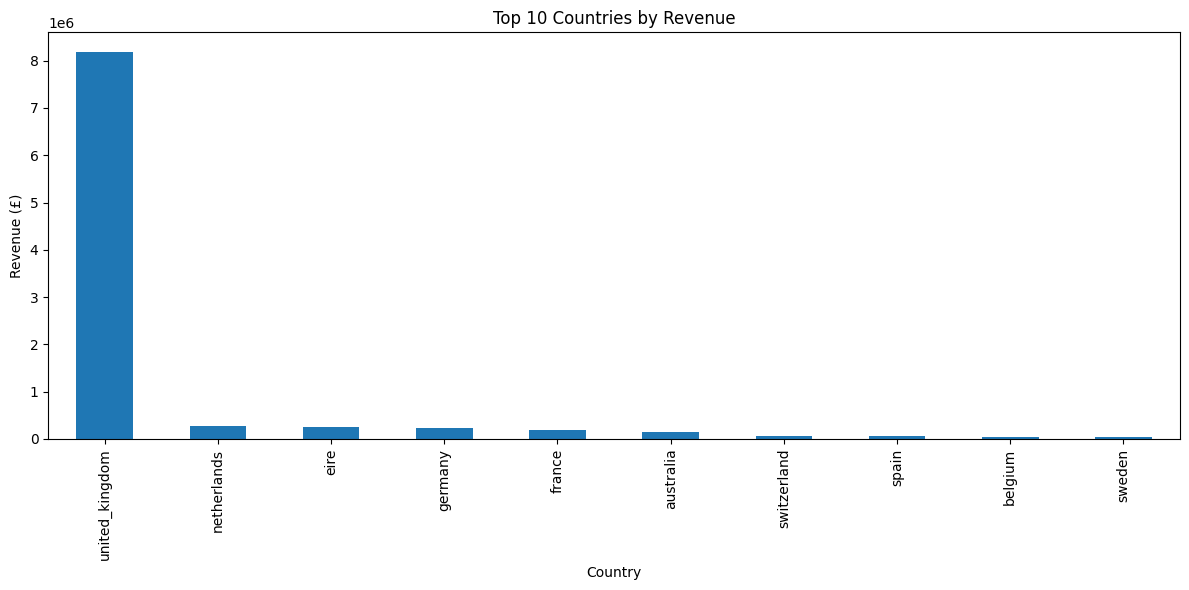

In [197]:
country_revenue.head(10).plot(kind="bar", figsize=(12,6))
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue (£)")
plt.tight_layout()
plt.savefig("../reports/figures/top_countries_revenue.png", dpi=300, bbox_inches='tight')
plt.show()

# 5. Top Customers by Revenue

### Which customers generate the most revenue?

In [198]:
customer_revenue=(
    df.groupby('customerid')['revenue']
    .sum()
    .sort_values(ascending=False)
)
customer_revenue

customerid
14646.0    279489.02
18102.0    256438.49
17450.0    187322.17
14911.0    132458.73
12415.0    123725.45
             ...    
12503.0     -1126.00
17603.0     -1165.30
14213.0     -1192.20
15369.0     -1592.49
17448.0     -4287.63
Name: revenue, Length: 4372, dtype: float64

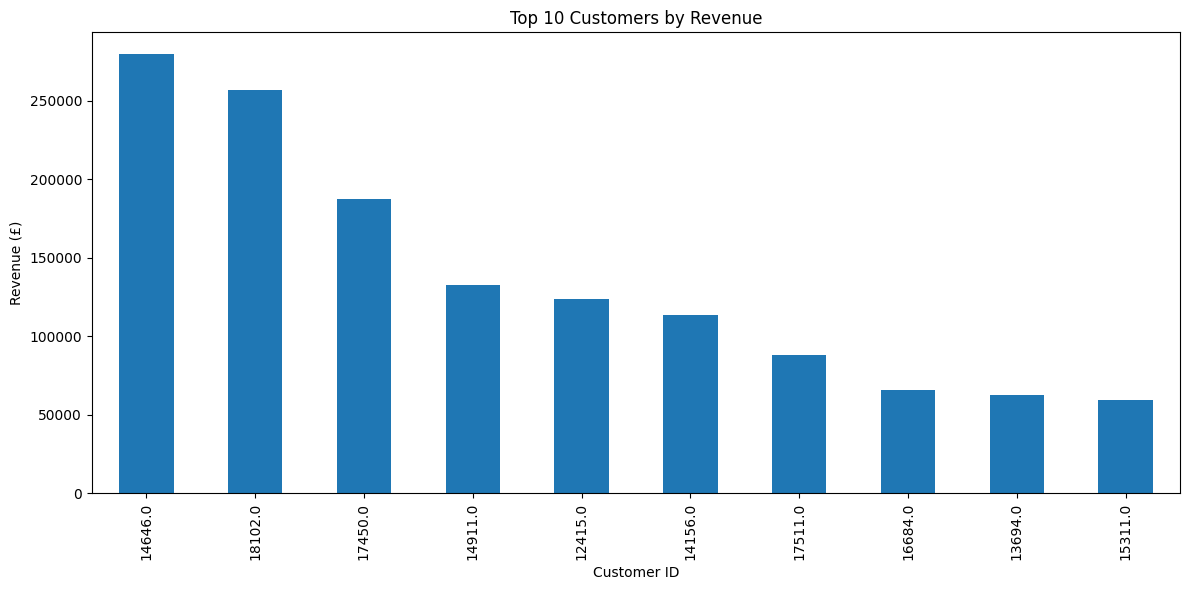

In [199]:
customer_revenue.head(10).plot(kind='bar', figsize=(12,6))
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue (£)")
plt.tight_layout()
plt.savefig("../reports/figures/top_customers_revenue.png", dpi=300, bbox_inches='tight')
plt.show()

# 6. Top Products by Revenue

### Which products generate the most revenue?

In [200]:
product_revenue = (
    df[
        (df["is_return"] == 0) &
        (~df["stockcode"].isin(["DOT", "POST", "M"]))
    ]
    .groupby("stockcode")["revenue"]
    .sum()
    .sort_values(ascending=False)
)


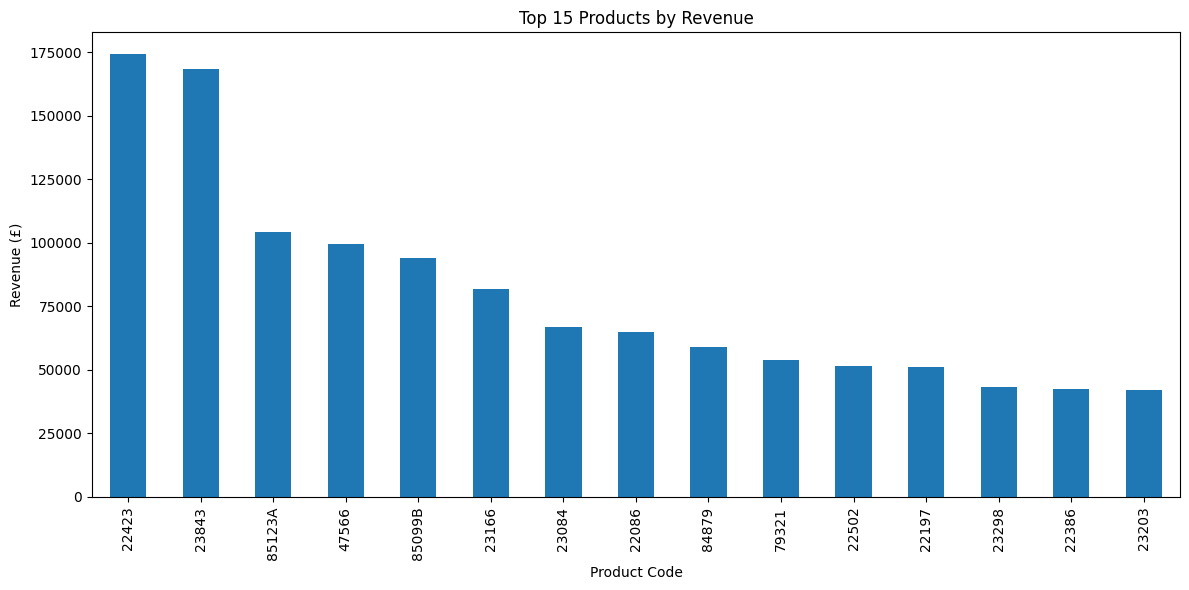

In [201]:
product_revenue.head(15).plot(kind='bar', figsize=(12, 6))
plt.title("Top 15 Products by Revenue")
plt.xlabel("Product Code")
plt.ylabel("Revenue (£)")
plt.tight_layout()
plt.savefig("../reports/figures/top_products_revenue.png", dpi=300, bbox_inches='tight')
plt.show()

# 7. Monthly Revenue Trend

### What are the revenue trends over time?

In [202]:
monthly_revenue=df.groupby(df['invoicedate'].dt.to_period('M'))['revenue'].sum()
monthly_revenue

invoicedate
2010-12     746723.610
2011-01     558448.560
2011-02     497026.410
2011-03     682013.980
2011-04     492367.841
2011-05     722094.100
2011-06     689977.230
2011-07     680156.991
2011-08     703510.580
2011-09    1017596.682
2011-10    1069368.230
2011-11    1456145.800
2011-12     432701.060
Freq: M, Name: revenue, dtype: float64

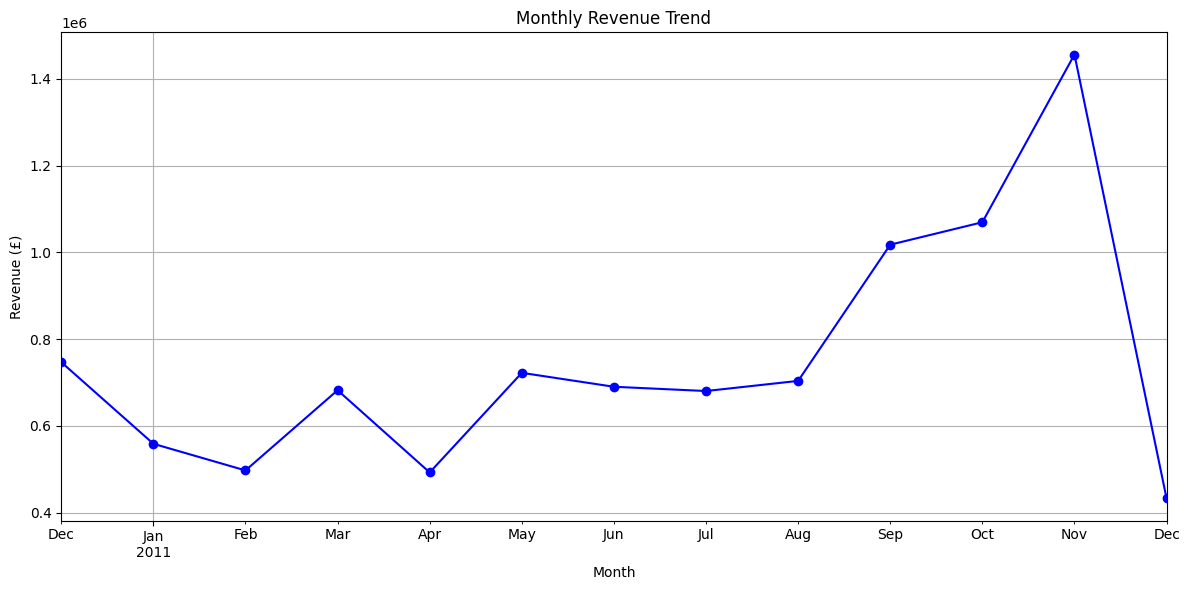

In [203]:
monthly_revenue.plot(kind='line',figsize=(12,6), marker='o', color='b')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.grid(True)
plt.tight_layout()
plt.savefig("../reports/figures/monthly_revenue_trend.png", dpi=300, bbox_inches='tight')
plt.show()


# 8. Orders by Hour of Day

### When is the best time to run advertisements?

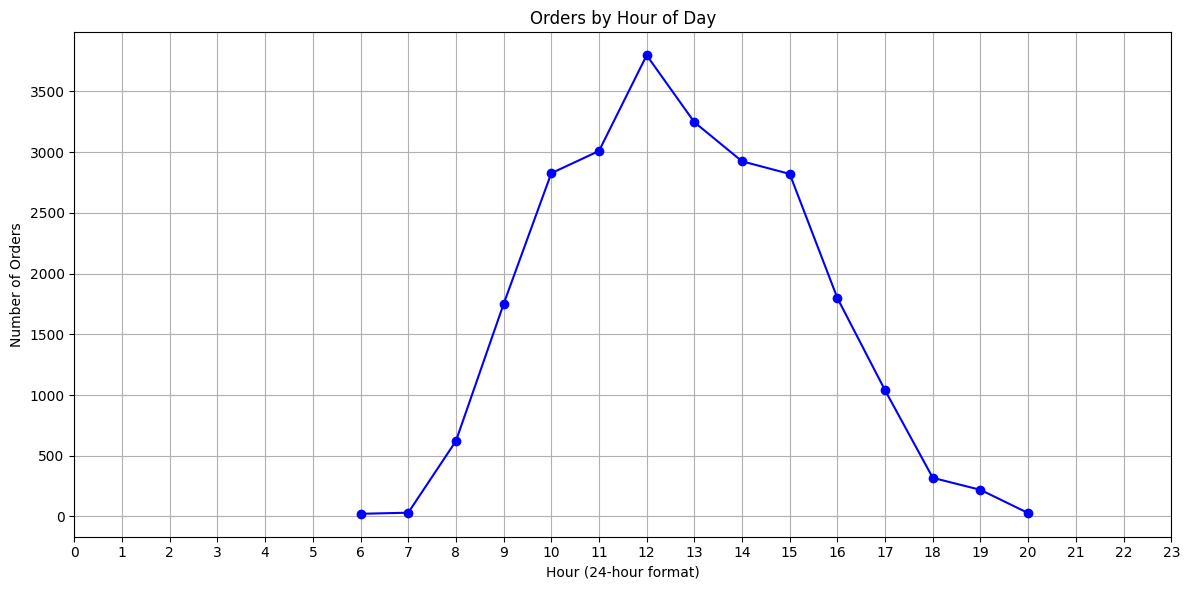

In [204]:
df['hour'] = df['invoicedate'].dt.hour

hourly_orders = df.groupby('hour')['invoiceno'].nunique()

plt.figure(figsize=(12,6))
plt.plot(hourly_orders.index, hourly_orders.values, marker='o',color='b')
plt.title('Orders by Hour of Day')
plt.xlabel('Hour (24-hour format)')
plt.ylabel('Number of Orders')
plt.xticks(range(0,24))
plt.grid(True)
plt.tight_layout()
plt.savefig("../reports/figures/orders_by_hour.png", dpi=300, bbox_inches='tight')
plt.show()

# 9. Return Rate by Country

### Which countries have the highest return rates?

USA shows 38.5%, followed by Czech Republic (16.7%) and Malta (11.8%). These are low-volume countries – filter before drawing conclusions.

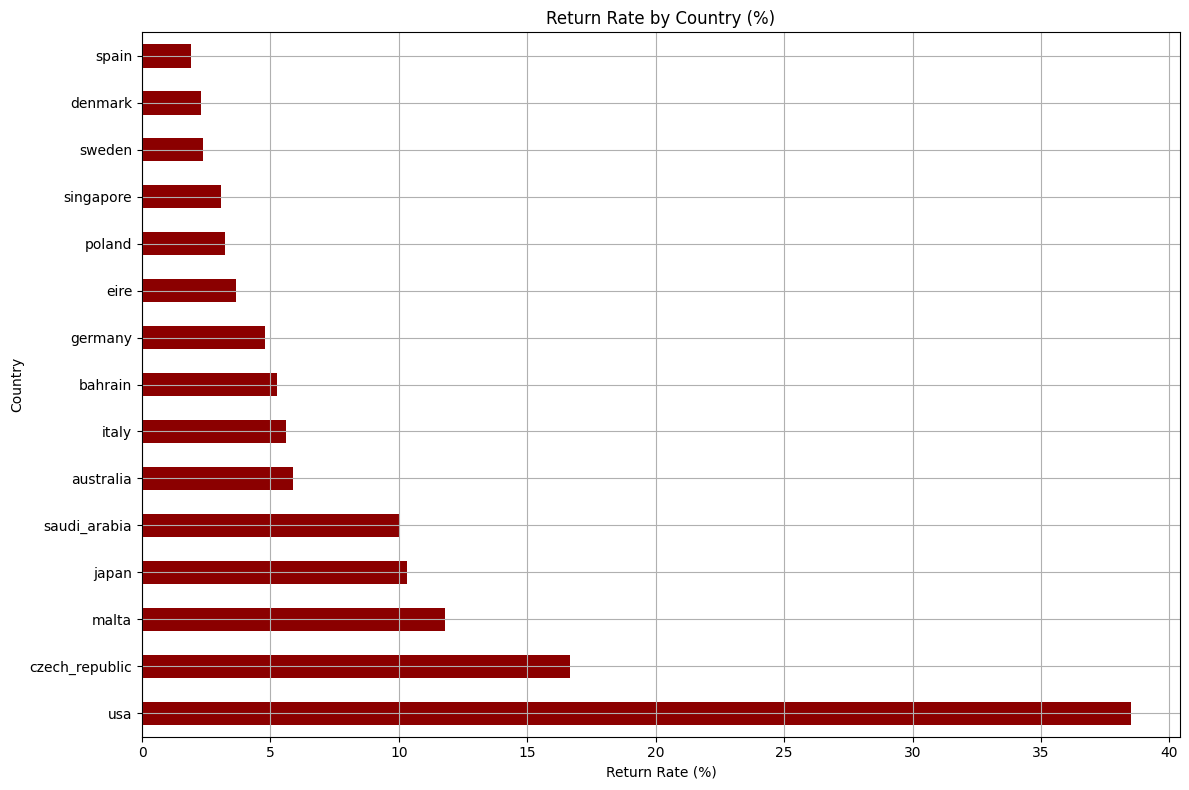

In [205]:
return_rate = (
    df.groupby('country')['is_return']
    .mean()
    .sort_values(ascending=False)
    .head(15)  
    * 100
)

plt.figure(figsize=(12,8))
return_rate.plot(kind='barh', color='#8B0000')
plt.title('Return Rate by Country (%)')
plt.xlabel('Return Rate (%)')
plt.ylabel('Country')
plt.grid(True)
plt.tight_layout()
plt.savefig("../reports/figures/return_rate_by_country.png", dpi=300, bbox_inches='tight')
plt.show()

# 10. Price vs Quantity Sold

### Is there a relationship between product price and quantity sold?

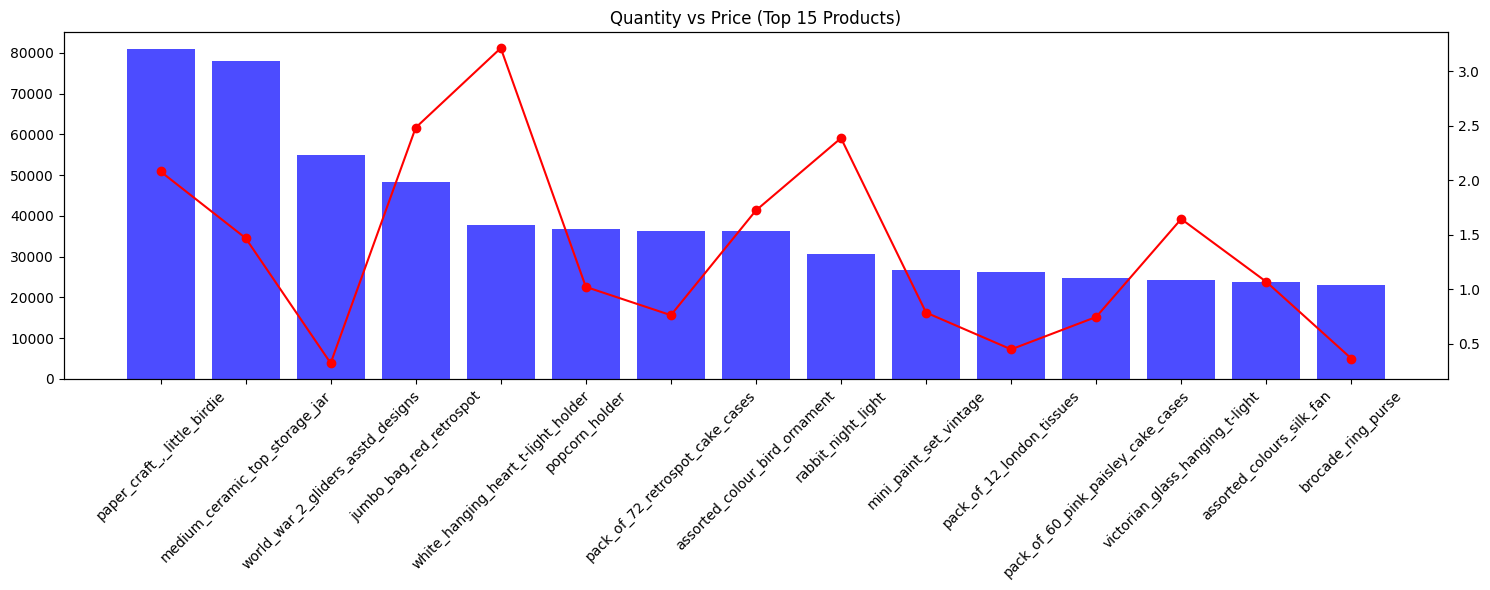

In [206]:
product_data = df[df['quantity'] > 0].groupby('description').agg(
    total_quantity=('quantity', 'sum'),
    avg_price=('unitprice', 'mean')
).sort_values('total_quantity', ascending=False).head(15)

fig, ax1 = plt.subplots(figsize=(15,6))
ax1.bar(product_data.index, product_data['total_quantity'], color='blue', alpha=0.7)
ax1.tick_params(axis='x', rotation=45)
ax2 = ax1.twinx()
ax2.plot(product_data.index, product_data['avg_price'], color='red', marker='o')
plt.title('Quantity vs Price (Top 15 Products)')
plt.tight_layout()
plt.savefig("../reports/figures/price_vs_quantity.png", dpi=300, bbox_inches='tight')
plt.show()

# 11. Frequently Bought Together

### What products are frequently bought together?

Top pair: `hand_warmer_red_polka_dot` + `hand_warmer_union_jack` (17 invoices).

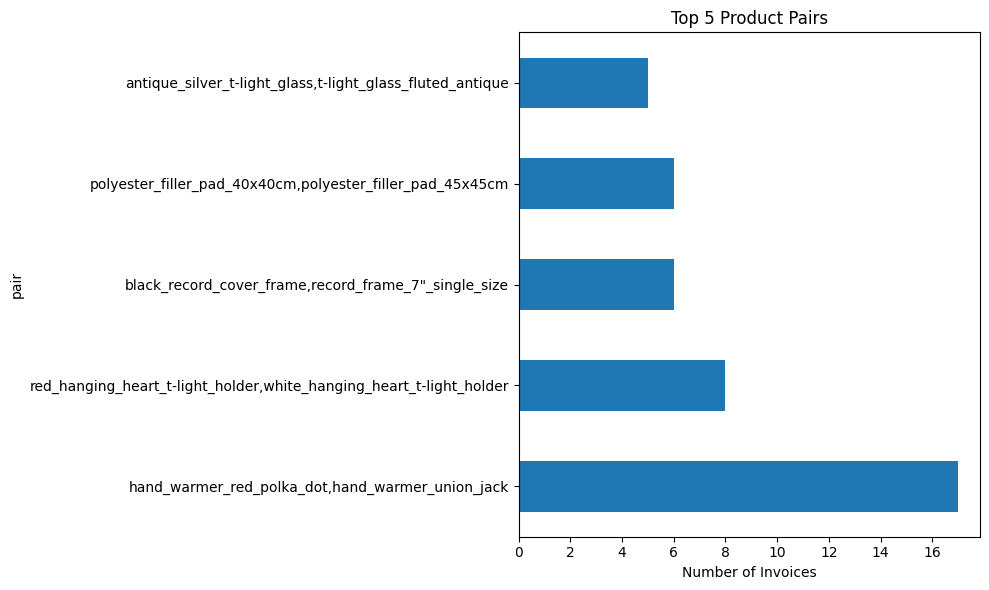

In [207]:
pairs_df = df[df['quantity'] > 0].copy()
# Filter out "manual" descriptions
pairs_df = pairs_df[~pairs_df['description'].str.contains('manual', case=False, na=False)]
# Keep only invoices with at least 2 items
invoice_counts = pairs_df.groupby('invoiceno')['description'].transform('count')
pairs_df = pairs_df[invoice_counts >= 2].copy()
# Sort alphabetically before joining
pairs_df['pair'] = pairs_df.groupby('invoiceno')['description'].transform(
    lambda x: ','.join(sorted(x))
)
top_pairs = pairs_df.drop_duplicates('invoiceno')['pair'].value_counts().head(5)

top_pairs.plot(kind='barh', figsize=(10,6))
plt.title('Top 5 Product Pairs')
plt.xlabel('Number of Invoices')
plt.tight_layout()
plt.savefig("../reports/figures/top_product_pairs.png", dpi=300, bbox_inches='tight')
plt.show()

# 12. Conclusions & Recommendations

**Key Findings:**
- Revenue is UK-centric (£8.2M); expand marketing to Netherlands, Ireland, Germany.
- Top customers drive ~3% of revenue each → implement VIP loyalty program.
- High-ticket products drive revenue → ensure stock availability.
- November revenue peak → increase ad budget Oct-Nov.
- Peak order hour: 12 PM → schedule email campaigns at lunchtime.
- USA shows 38.5% return rate (low volume); Australia (~5.9%) and Germany (~4.8%) are more reliable benchmarks – investigate logistics.
- Cheap items sell high volume → use as loss leaders for upselling.
- Top product pair: hand_warmer_red_polka_dot + hand_warmer_union_jack → bundle them.

**Next Steps:**
- Customer segmentation for targeted retention.
- Calculate Customer Lifetime Value (CLV).
- Advanced market basket analysis (support, confidence, lift).
- A/B test email timing.
- Investigate Germany and Australia return rate drivers.

# 13. Save Processed Data

Saving the enriched dataset with `revenue` and `is_return` for future use.

In [208]:
df.to_csv("../data/processed/online_retail_data_clean_eda.csv",index=False)